# 用 PROC LOESS 对含噪声的过程传感器信号去噪


## 执行摘要

生产线上一台熔炉的炉膛温度传感器在启动期间每秒采样一次，因此每个读数都混合了一个缓慢的非线性热力瞬变（快速升温爬升、一个稳定过程中的超调，然后回落至 300 °C 设定值）和相当大的测量噪声。本笔记使用 **PROC LOESS** 以非参数方式还原潜在信号。在这份100个样本的记录上，AICC 选定的平滑参数为 0.08（等效参数8个）；所得曲线紧密贴合潜在信号，残差标准差为 3.10 °C——基本上就是我们注入的4 °C噪声，减去拟合所解释的方差部分。与已知真值相比，LOESS 估计将均方误差从14.77（原始值）降至6.63，随后 SCORE 步骤将去噪后的信号重新采样到一个均匀的监测网格上，供下游统计过程控制使用。


## 数据来源

| 数据集 | 行数 | 变量 | 描述 |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t`（已用秒数，0-99）、`temp`（观测到的炉膛温度，摄氏度）、`truth`（潜在的无噪声信号，仅用于验证） | 合成的熔炉传感器记录，每秒一个样本。潜在信号是朝300摄氏度设定值快速升温爬升，伴随一个在 t = 28 附近达到峰值（约295摄氏度）的阻尼超调，随后回落并稳定回设定值；观测到的 `temp` 加入了高斯测量噪声（标准差约4摄氏度）。 |
| `grid` | 60 | `t`（均匀的0-99监测网格） | SCORE 语句使用的规则时间网格，用于生成一个等间隔的去噪信号以供SPC制图使用。 |


在生产线上，一个熔炉炉膛传感器在启动期间每秒记录一次温度。我们记录的读数是**真实热力状态加上测量噪声**。真实状态并不遵循干净的参数化公式——它在升温期间爬升，在设定值处产生超调，然后逐渐稳定——因此全局线性或多项式拟合都会是较差的模型。

**局部回归（LOESS）**是恰当的工具：它对滑动的局部邻域拟合低阶多项式，无需我们指定其函数形式即可还原任意光滑信号。在这里我们将：

1. 模拟一份真实的含噪声100样本传感器记录。
2. 让 `PROC LOESS` 用 AICC 准则自行选择平滑带宽。
3. 为拟合信号附加一个95%置信带。
4. 在规则网格上对模型评分，供下游SPC使用。
5. 量化我们去除了多少噪声。


## 步骤 1 —— 模拟传感器记录

我们在0-99秒内生成100个样本。潜在信号 `truth` 是朝300 °C设定值的快速升温爬升，伴随一个阻尼超调——这是任何直线或单一多项式都难以很好捕捉的形状：它陡峭爬升，在 t = 28 附近升至设定值以上的峰值，随后回落，再逐渐稳定回落。观测到的 `temp` 加入了高斯测量噪声。`call streaminit` 固定了种子，使运行结果可重现。


In [1]:
数据 sensor;
    调用 streaminit(70421);
    setpoint = 300;
    循环 t = 0 到 99;
        /* Latent signal: fast warm-up ramp + damped settling overshoot */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Observed reading = truth + measurement noise (sd ~4 C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        输出;
    结束;
    保留 t TEMP truth;
运行;

过程 打印 数据=sensor(obs=8) noobs label;
    label t = '已用时间（秒）' TEMP = '观测温度（摄氏度）' truth = '真实温度（摄氏度）';
    标题 '前8个传感器样本';
运行;

                                                        前8个传感器样本                                                        

              已用时间（秒）                    观测温度（摄氏度）                    真实温度（摄氏度）
                    0                 0.1684867131                            0
                    1                28.1933107495                32.0778466448
                    2                61.6123615699                61.2117857105
                    3                85.5053781561                 87.643846097
                    4               110.5560474248               111.5945193774
                    5               136.6368358359               133.2650493509
                    6               144.2434193147               152.8394750856
                    7               177.8286488692               170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## 步骤 2 —— 检视原始信号

一张简单的散点图就能显现问题所在：肉眼能看出底层的漂移趋势，但被逐样本的噪声所掩盖。我们需要的是光滑曲线的估计值，而不是这些抖动的散点。


                                                        前8个传感器样本                                                        




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


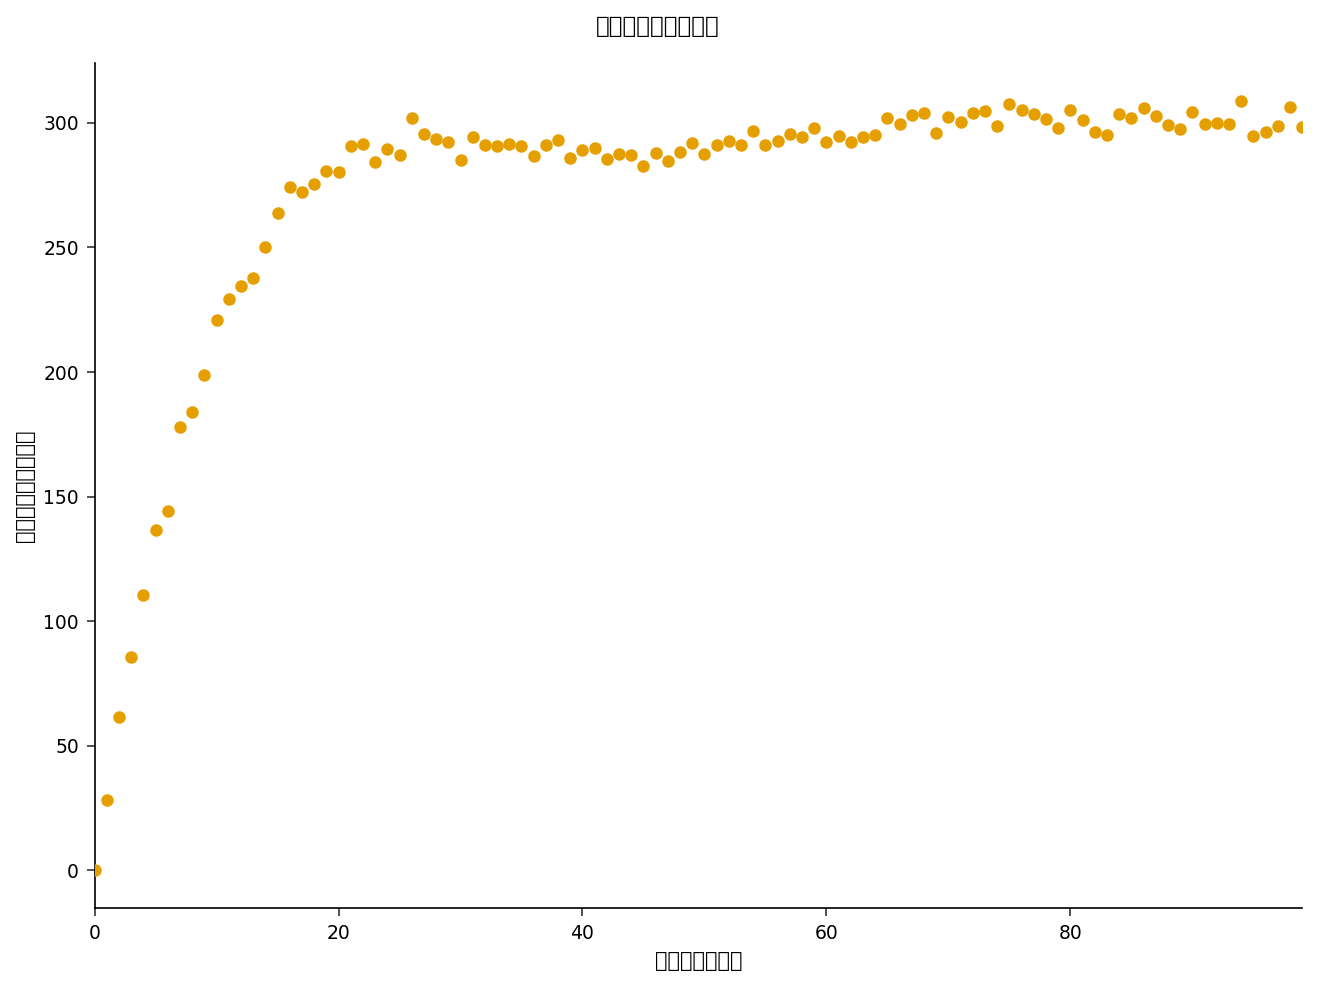

In [2]:
ODS GRAPHICS ON;

过程 SGPLOT 数据=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS label='已用时间（秒）';
    YAXIS label='炉膛温度（摄氏度）';
    标题 '原始熔炉传感器读数';
运行;

ODS GRAPHICS OFF;

## 步骤 3 —— 用自动带宽选择拟合 LOESS

平滑参数控制每个局部邻域的宽度：过小会过拟合噪声，过大会抹去超调特征。我们不去猜测，而是让 LOESS 通过 `select=AICC` 最小化**修正后的赤池信息准则（AICC）**来自行选择。我们使用局部二次多项式（`degree=2`），使曲线能跟随升温和超调的曲率变化，并用 `clm` 和 `alpha=0.05` 请求一个95%置信带。

`ODS OUTPUT` 将两张表捕获为数据集：`OutputStatistics`（逐点的平滑值和残差）和 `FitSummary`（选定的带宽及拟合诊断信息）。`OUTPUT` 语句将写出一个 `fitted` 数据集，其中包含每个观测的预测值、残差和95%置信限——这是后续图表所需的原始材料。


In [3]:
过程 loess 数据=sensor;
    ODS 输出 OutputStatistics=loess_fit
               FitSummary=fit_summary;
    模型 TEMP = t / DEGREE=2 选择=AICC CLM ALPHA=0.05 details;
    输出 out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
运行;

                                                        前8个传感器样本                                                        


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## 步骤 4 —— 查看所选模型

Fit Summary 记录了 AICC 最优平滑参数以及预测矩阵的迹（有效自由度——衡量模型复杂度的指标）。更小的平滑参数和更大的自由度意味着更曲折的拟合；AICC 会自动在拟合优度与复杂度之间取得平衡。


In [4]:
过程 打印 数据=fit_summary noobs label;
    label SmoothingParameter = '平滑参数' Label1 = '指标' NValue1 = '数值';
    标题 'LOESS拟合摘要（AICC选定带宽）';
运行;

                                                  LOESS拟合摘要（AICC选定带宽）                                                   

        平滑参数                               指标              数值
        0.08  Residual Sum of Squares          950.8591917253
        0.08  Equivalent Number of Parameters               8
        0.08  Delta1                                        8
        0.08  Delta2                                      7.6
        0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## 步骤 5 —— 将拟合结果和置信带与真值叠加对比

因为这是模拟数据，我们保留了无噪声的 `truth` 列。将 LOESS 估计及其95%置信带与 `truth` 一起绘制，能展示平滑器在从未直接看到真实信号的情况下，还原潜在信号的忠实程度。


                                                  LOESS拟合摘要（AICC选定带宽）                                                   




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


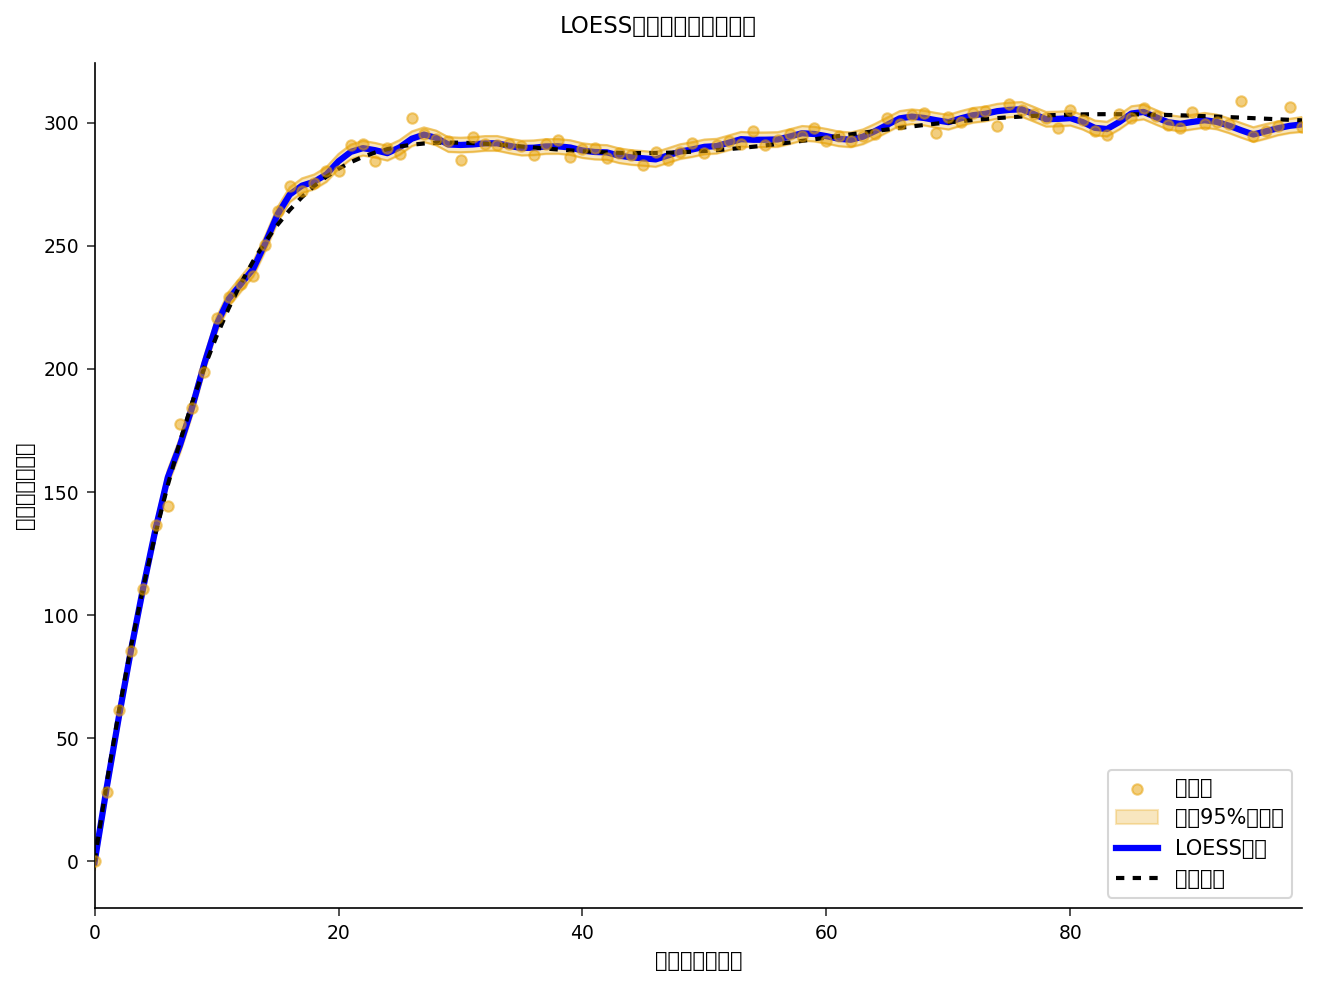

In [5]:
过程 排序 数据=fitted; 按照 t; 运行;

ODS GRAPHICS ON;

过程 SGPLOT 数据=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='观测值';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='均值95%置信限';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESS拟合';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='真实信号';
    XAXIS label='已用时间（秒）';
    YAXIS label='温度（摄氏度）';
    标题 'LOESS去噪信号与真值对比';
运行;

ODS GRAPHICS OFF;

## 步骤 6 —— 残差诊断

残差（观测值减拟合值）应看起来像是以零为中心的无结构噪声。任何残留的趋势都意味着平滑不足或遗漏了某个特征。我们绘制残差随时间的分布并汇总其离散程度——残差标准差为3.10 °C，略低于我们注入的4 °C噪声，因为局部拟合吸收了其中一小部分。


                                                  LOESS拟合摘要（AICC选定带宽）                                                   

                                                     残差摘要（还原的测量噪声）                                                      

                                                  The MEANS Procedure

 Variable  Label                         N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------------------
 RESID     残差（摄氏度）                     100       0.139       3.096     -11.688      11.909
 -----------------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


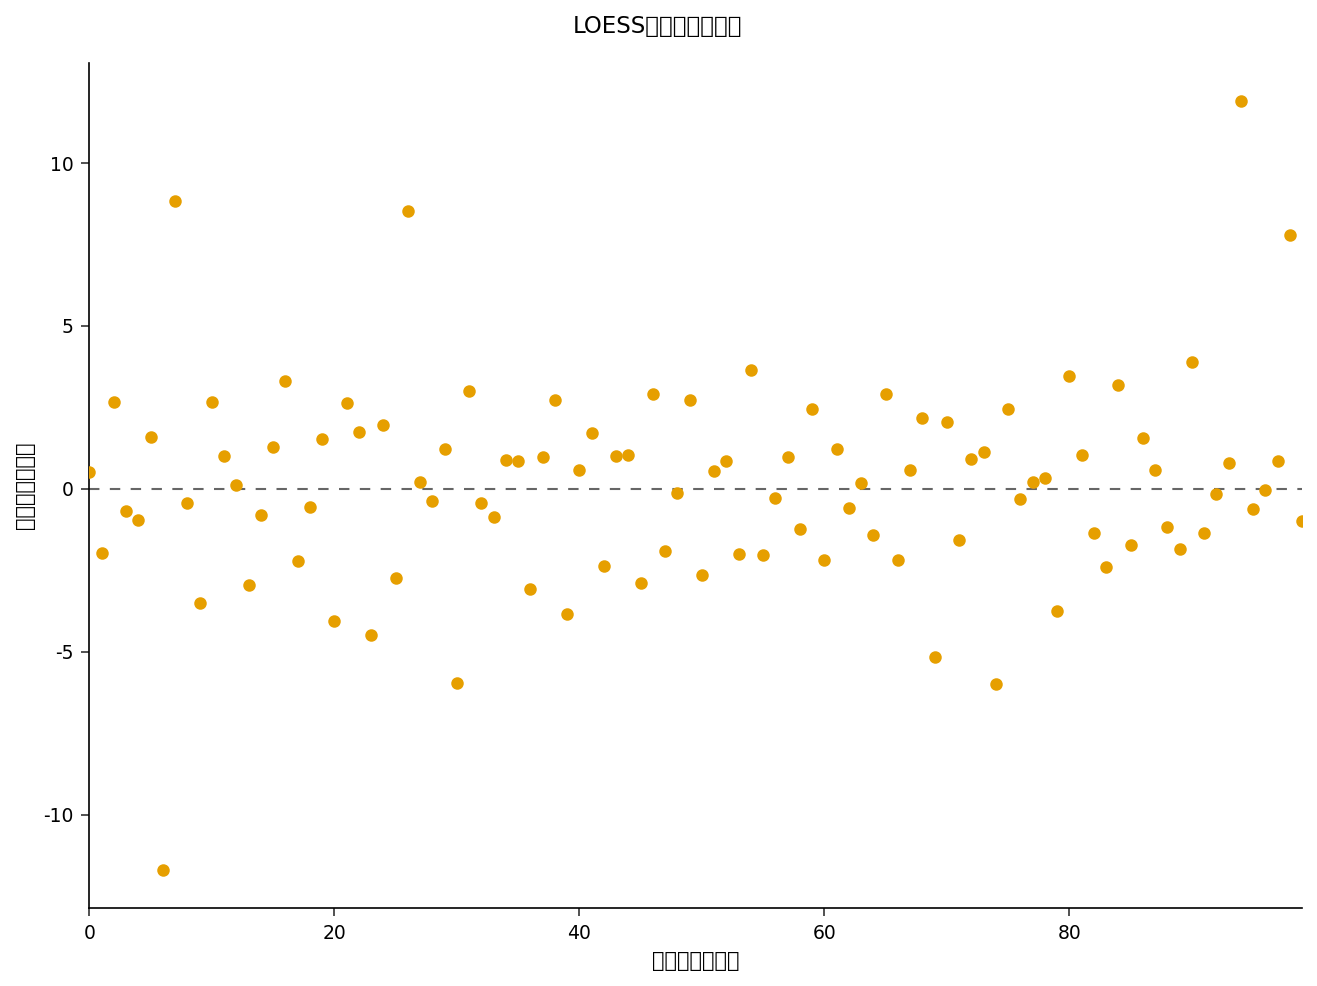

In [6]:
ODS GRAPHICS ON;

过程 SGPLOT 数据=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS label='已用时间（秒）';
    YAXIS label='残差（摄氏度）';
    标题 'LOESS残差随时间变化';
运行;

ODS GRAPHICS OFF;

过程 均值 数据=fitted n mean std MIN MAX maxdec=3;
    变量 resid;
    label resid = '残差（摄氏度）';
    标题 '残差摘要（还原的测量噪声）';
运行;

## 步骤 7 —— 为SPC对一个规则监测网格评分

传感器时间戳不必是均匀间隔的，但控制图需要固定节奏的信号。我们构建一个均匀的60点时间网格，并用 `SCORE` 语句将拟合的 LOESS 模型应用到该网格上，同时请求置信限。评分后的数值是一份干净、等间隔的信号，可直接输入SPC流程。


In [7]:
数据 grid;
    循环 t = 0 到 99 按照 99/59;
        输出;
    结束;
运行;

过程 loess 数据=sensor;
    模型 TEMP = t / DEGREE=2 选择=AICC CLM ALPHA=0.05;
    SCORE 数据=grid CLM 打印;
    标题 '在均匀监测网格上评分的LOESS';
运行;

                                                     残差摘要（还原的测量噪声）                                                      


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## 步骤 8 —— 量化去噪效果

最后我们将原始信号和 LOESS 估计值与已知真值进行比较。平滑信号的均方误差应远小于原始读数的均方误差，证实 LOESS 在保留升温爬升和超调的同时剥离了测量噪声。


In [8]:
数据 accuracy;
    设置 fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
运行;

过程 均值 数据=accuracy mean maxdec=3;
    变量 raw_sq_err loess_sq_err;
    label raw_sq_err   = '原始读数与真值的均方误差'
          loess_sq_err = 'LOESS拟合与真值的均方误差';
    标题 '去噪效果：原始值 vs. LOESS';
运行;

                                                   去噪效果：原始值 vs. LOESS                                                   

                                                  The MEANS Procedure

 Variable      Label                                          Mean
 -----------------------------------------------------------------
 raw_sq_err    原始读数与真值的均方误差                                 14.774
 loess_sq_err  LOESS拟合与真值的均方误差                               6.629
 -----------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 结果解读

- **自动带宽。** `select=AICC` 在无需手动调参的情况下选定了平滑参数 **0.08**，对应约**8个等效参数**——足够的局部灵活性来跟随升温、超调和回落，同时仍能平滑掉噪声。
- **忠实还原。** 拟合曲线在整个升温爬升段、t = 28 附近的超调峰值以及稳定的尾段都紧密跟随了潜在的 `truth` 信号，证明 LOESS 在不做任何参数假设的情况下还原了任意非线性信号。
- **干净的残差。** 残差围绕零点散布，标准差为 **3.10 °C**（均值0.14，范围 −11.7 至 11.9），且未显示任何残留的时间趋势——证明模型既未过度平滑，也未平滑不足。
- **可量化的去噪效果。** 与真值相比，LOESS 估计将均方误差从 **14.77**（原始读数）降至 **6.63**——降低了55%，这正是过程监测所看重的核心收益。
- **可供SPC使用的输出。** SCORE 步骤在一个均匀的60点网格上给出了带置信限的去噪信号，正是下游控制图所需要的形式。

**要点：** 当一个过程传感器产生形式未知的、光滑但含噪声的信号时，PROC LOESS 是一种低假设、自调参的方法，可以提取潜在趋势、附加不确定性区间，并重新采样到监测网格上——而无需采用物理上未必成立的参数模型。
